# Bias-Variance Tradeoff and Regularization

## Learning Objectives

By the end of this lab, you will be able to:

- Explain **underfitting** and **overfitting**.
- Understand **bias** and **variance**.
- Explain the **bias-variance tradeoff**.
- Understand why a model can perform very well on training data but poorly on unseen data.
- Understand **regularization** as a technique to reduce overfitting.
- Understand **L2 regularization**.
- Implement L2 regularization manually.
- Understand the role of the **learning rate**, **iterations**, and **regularization parameter**.
- Compare models with and without regularization.
- Use a built-in regularized model from Scikit-Learn.

## What Problem Are We Trying to Solve?

A machine learning model should learn the **general pattern** in the data.

It should not:

- be too simple and miss the pattern
- memorize the training data
- learn random noise as if it were a real pattern

There are three common situations:

### Underfitting
The model is **too simple** and cannot learn the important pattern.

### Good Fit
The model learns the important pattern and works well on new data.

### Overfitting
The model is **too complex** and learns the training data too closely, including noise.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)

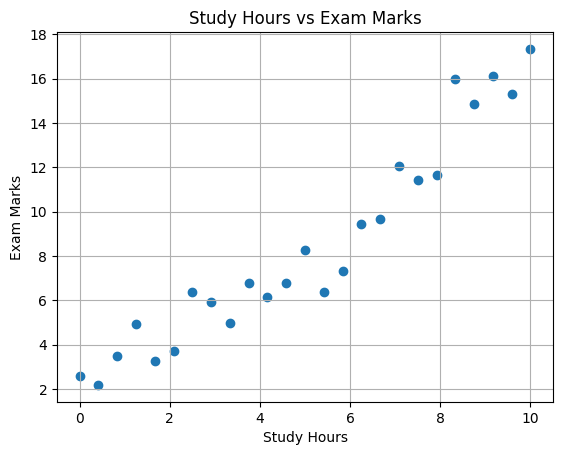

In [3]:
 # Study hours
X = np.linspace(0, 10, 25)

# Exam marks with a curved relationship + some noise
y = 2 + 0.8 * X + 0.08 * X**2 + np.random.normal(0, 1.2, len(X))

plt.scatter(X, y)
plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Study Hours vs Exam Marks")
plt.grid(True)
plt.show()

## What Is Model Complexity?

Model complexity describes how flexible a model is.

For polynomial regression:

- Degree 1 → straight line
- Degree 2 → simple curve
- Degree 5 → more flexible curve
- Very high degree → very flexible model

A more complex model can learn more complicated patterns.

However, **more complex does not always mean better**.

A very complex model may start learning the noise in the training data.

What does degree actually do?

Degree 1:

$$ y = b_0 + b_1x $$

For 6 hours, model basically calculates using x only → a straight-line relationship.

Degree 2:

$$ y = b_0 + b_1x + b_2x^2 $$

Now for 6 hours, the model uses 6 and 6² = 36.
This gives it the ability to make a curve rather than only a straight line.

Degree 3:

$$ y = b_0 + b_1x + b_2x^2 + b_3x^3 $$

For 6 hours → it can use 6, 36, 216.

So the idea is:

Increasing the degree doesn't mean we're changing the study hours. We're giving the model more mathematical features of the same x (x², x³, etc.) so it can learn more complicated relationships between study hours and marks.

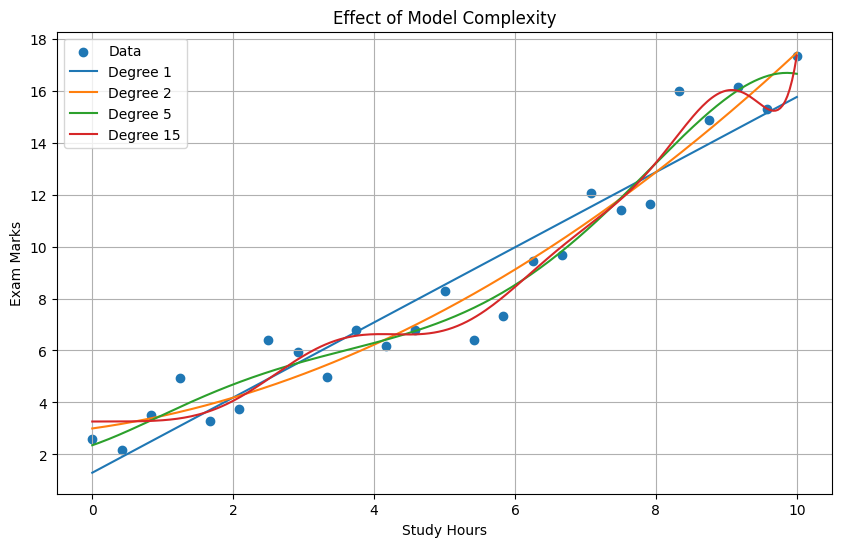

In [4]:
# Create a range of values for drawing smooth curves
X_plot = np.linspace(0, 10, 300)

plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Data")

for degree in [1, 2, 5, 15]:
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X.reshape(-1, 1), y)

    y_plot = model.predict(X_plot.reshape(-1, 1))

    plt.plot(
        X_plot,
        y_plot,
        label=f"Degree {degree}"
    )

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Effect of Model Complexity")
plt.legend()
plt.grid(True)
plt.show()

### What should you notice?

A low-degree model may be too simple.

As the degree increases, the model becomes more flexible.

At a very high degree, the model can start making unnecessary curves to fit the training points.

This is one way **overfitting** can happen.

## Practice 1

Try changing the polynomial degrees in the previous cell.

```python
# Try:
# degree = 1
# degree = 3
# degree = 7
# degree = 20

## Training Error and Validation Error

We should not judge a model only by how well it performs on the data it has already seen.

### Training Error

Error calculated using the **training data**.

### Validation Error

Error calculated using **unseen data**.

A model that is overfitting may have:

- Very low training error
- High validation error

This is an important sign of overfitting.

In [5]:
# Split the data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X.reshape(-1, 1),
    y,
    test_size=0.30,
    random_state=42
)

results = []

for degree in [1, 2, 5, 10, 15]:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    val_predictions = model.predict(X_val)

    train_mse = mean_squared_error(
        y_train,
        train_predictions
    )

    val_mse = mean_squared_error(
        y_val,
        val_predictions
    )

    results.append([
        degree,
        train_mse,
        val_mse
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Training MSE",
        "Validation MSE"
    ]
)

results_df

,Degree,Training MSE,Validation MSE
0,1,1.685010,2.109778
1,2,0.971138,1.423980
2,5,0.831451,1.647702
3,10,0.677951,1556.210394
4,15,0.776185,2.207127


### What should you look for?

As the model becomes more complex:

- Training error may continue to decrease.
- Validation error may decrease at first.
- After a certain point, validation error may start increasing.

This is a common pattern of **overfitting**.

The important idea is:

> A model should perform well not only on training data, but also on unseen data.

## Practice 2

Look at the table above.

Without changing the code, answer:

1. Which model is the simplest?
2. Which models have higher complexity?
3. Does training error always decrease as complexity increases?
4. What happens to validation error?
5. Why might a very complex model perform poorly on unseen data?

## Bias

**Bias** is error caused by a model being too simple or making overly strong assumptions.

For example:

If the real relationship is curved but we use a simple straight line, the model may fail to capture the pattern.

This is called **high bias**.

### Remember:

**High Bias → Model is too simple → Underfitting**

## Variance

**Variance** describes how sensitive a model is to the particular training data it receives.

A model with high variance can change a lot when the training data changes slightly.

Very complex models are often more sensitive to the training data.

### Remember:

**High Variance → Model is too sensitive → Overfitting**

## Bias-Variance Tradeoff

There is a tradeoff between bias and variance.

As model complexity increases:

- Bias generally decreases.
- Variance generally increases.

So:

**Simple model → High Bias, Low Variance**

**Complex model → Low Bias, High Variance**

Our goal is to find a useful balance where the model generalizes well to unseen data.

### Easy way to remember

**Bias = too simple**

**Variance = too sensitive**

## Why Do We Need Regularization?

We have seen that a complex model can overfit.

One way to reduce overfitting is **regularization**.

Regularization adds a penalty to the model when its weights become too large.

The model now tries to do two things:

1. Fit the data well.
2. Keep the weights smaller.

So regularization discourages the model from becoming unnecessarily complex.

## L2 Regularization

One common type of regularization is called **L2 Regularization**.

The basic idea is:

**Total Cost = Prediction Loss + Regularization Penalty**


Large weights → larger penalty

Small weights → smaller penalty


In [6]:
def create_polynomial_features(x, degree):
    features = []

    for power in range(1, degree + 1):
        features.append(x ** power)

    return np.column_stack(features)

In [7]:
# Example

example_x = np.array([2, 3, 4])

example_features = create_polynomial_features(
    example_x,
    degree=3
)

print(example_features)

[[ 2  4  8]
 [ 3  9 27]
 [ 4 16 64]]


For degree 3, the features are:

`x, x², x³`

So for `x = 2`:

`[2, 4, 8]`

The model can now learn a separate weight for each of these features.

## Cost Function With L2 Regularization

First, remember the normal Mean Squared Error idea:

**Prediction Error = How far predictions are from actual values**

With regularization, we add another part:

**Regularization Penalty = Penalty for large weights**

Therefore:

**Total Cost = Prediction Error + Regularization Penalty**

We will not regularize the bias `b` in this implementation.

In [8]:
def compute_cost_l2(X, y, w, b, lambda_):

    m = len(y)

    # Predictions
    predictions = X @ w + b

    # Prediction error
    error = predictions - y

    # Normal MSE part
    mse = (1 / (2 * m)) * np.sum(error ** 2)

    # L2 regularization penalty
    penalty = (lambda_ / (2 * m)) * np.sum(w ** 2)

    # Total cost
    total_cost = mse + penalty

    return total_cost

### `lambda_`

`lambda_` controls the strength of regularization.

- `lambda_ = 0` → no regularization
- Small `lambda_` → weak regularization
- Large `lambda_` → strong regularization

A larger value puts more pressure on the model to keep its weights small.

## Gradient Descent With L2 Regularization

The basic process:

1. Make predictions.
2. Calculate the gradients.
3. Update the parameters.
4. Repeat.

Regularization adds an extra term to the weight gradient.


In [12]:
def compute_gradients_l2(X, y, w, b, lambda_):

    m = len(y)

    # Predictions
    predictions = X @ w + b

    # Error
    error = predictions - y

    # Gradient for weights
    dw = (1 / m) * (X.T @ error) + (lambda_ / m) * w

    # Gradient for bias
    db = (1 / m) * np.sum(error)

    return dw, db


Now we will put everything together.

Our function will:

1. Start with initial weights and bias.
2. Calculate gradients.
3. Update the weights and bias.
4. Calculate the cost.
5. Repeat this process many times.
6. Return the learned parameters and cost history.

In [13]:
def gradient_descent_l2(
    X,
    y,
    w_initial,
    b_initial,
    learning_rate,
    iterations,
    lambda_
):

    w = w_initial.copy()
    b = b_initial

    cost_history = []

    for i in range(iterations):

        # Calculate gradients
        dw, db = compute_gradients_l2(
            X, y, w, b, lambda_
        )

        # Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Calculate cost
        cost = compute_cost_l2(
            X, y, w, b, lambda_
        )

        cost_history.append(cost)

    return w, b, cost_history

## Important Gradient Descent Settings

Before training, we need to choose:

### Initial weights

Where the model starts.

### Learning rate

Controls the size of each update.

- Too large → updates may become unstable.
- Too small → learning can be very slow.

### Number of iterations

How many times Gradient Descent updates the parameters.

### `lambda_`

Controls the strength of regularization.

These are important **hyperparameters**.

## Train a High-Degree Model Without Regularization

First, we will deliberately use a relatively complex model.

We will set:

`lambda_ = 0`

This means there is no regularization.

This gives us a baseline to compare with.

In [14]:
degree = 10

X_poly = create_polynomial_features(X, degree)

# Scale polynomial features
X_poly = X_poly / np.max(np.abs(X_poly), axis=0)

# Initial parameters
w_initial = np.zeros(X_poly.shape[1])
b_initial = 0.0

# Gradient Descent settings
learning_rate = 0.01
iterations = 10000

# No regularization
lambda_ = 0.0

w_no_reg, b_no_reg, cost_no_reg = gradient_descent_l2(
    X_poly,
    y,
    w_initial,
    b_initial,
    learning_rate,
    iterations,
    lambda_
)

print("Learned weights:")
print(w_no_reg)

print("\nLearned bias:")
print(b_no_reg)

print("\nFinal cost:")
print(cost_no_reg[-1])

Learned weights:
[ 5.89290041  4.24437415  3.06243096  2.10526217  1.2822721   0.57239771
 -0.03242914 -0.54086685 -0.96341675 -1.31127404]

Learned bias:
2.8976123223651102

Final cost:
0.46655267821057267


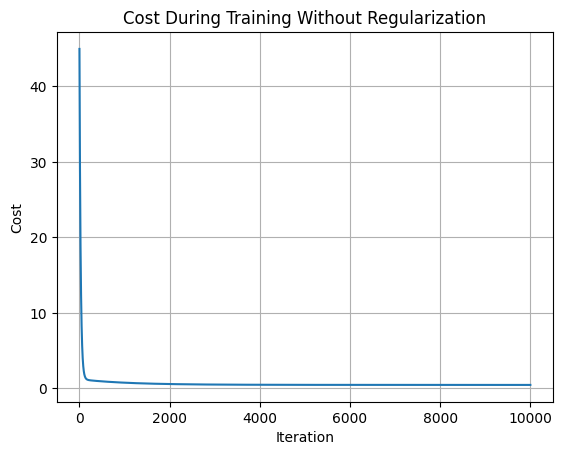

In [15]:
plt.plot(cost_no_reg)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Training Without Regularization")

plt.grid(True)
plt.show()

## Practice 4

Try changing:

```python
learning_rate = 0.00001
iterations = 10000


## Add Regularization

Now we will train the same model again.

The only major change is:

`lambda_ > 0`

This means we now penalize large weights.

In [16]:
lambda_ = 10.0

w_reg, b_reg, cost_reg = gradient_descent_l2(
    X_poly,
    y,
    np.zeros(X_poly.shape[1]),
    0.0,
    learning_rate,
    iterations,
    lambda_
)

print("Learned weights:")
print(w_reg)

print("\nLearned bias:")
print(b_reg)

print("\nFinal regularized cost:")
print(cost_reg[-1])

Learned weights:
[1.4892267  1.44478942 1.27727606 1.11477214 0.97563217 0.85971185
 0.76354889 0.68353566 0.61658812 0.56021247]

Learned bias:
6.079945953308209

Final regularized cost:
4.712639404818557


## Compare the Weights

Regularization should encourage the weights to become smaller.

Let's compare the weights from both models.

In [17]:
comparison = pd.DataFrame({
    "Without Regularization": w_no_reg,
    "With Regularization": w_reg
})

comparison

,Without Regularization,With Regularization
0,5.892900,1.489227
1,4.244374,1.444789
2,3.062431,1.277276
3,2.105262,1.114772
4,1.282272,0.975632
5,0.572398,0.859712
6,-0.032429,0.763549
7,-0.540867,0.683536
8,-0.963417,0.616588
9,-1.311274,0.560212


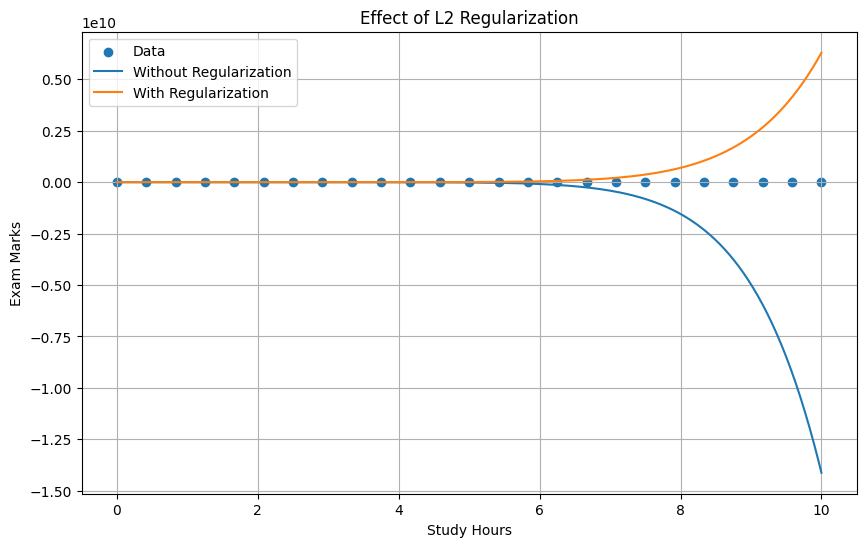

In [18]:
X_plot = np.linspace(0, 10, 300)

X_plot_poly = create_polynomial_features(
    X_plot,
    degree
)

pred_no_reg = X_plot_poly @ w_no_reg + b_no_reg
pred_reg = X_plot_poly @ w_reg + b_reg

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Data"
)

plt.plot(
    X_plot,
    pred_no_reg,
    label="Without Regularization"
)

plt.plot(
    X_plot,
    pred_reg,
    label="With Regularization"
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Effect of L2 Regularization")

plt.legend()
plt.grid(True)
plt.show()



The model without regularization has more freedom to fit the data.

Regularization discourages very large weights, making the model less extreme.

The goal is not to make the model as simple as possible.

The goal is to reduce unnecessary complexity so that the model can **generalize better**.
#### What Happens When `lambda_` Changes?

Let's experiment with different regularization strengths.

Remember:

- `lambda_ = 0` → no regularization
- Small value → weak regularization
- Large value → strong regularization

In [ ]:
lambda_values = [0, 0.1, 1, 10, 100]

for lambda_ in lambda_values:

    w_temp, b_temp, cost_temp = gradient_descent_l2(
        X_poly,
        y,
        np.zeros(X_poly.shape[1]),
        0.0,
        learning_rate,
        iterations,
        lambda_
    )

    predictions = X_poly @ w_temp + b_temp

    mse = mean_squared_error(
        y,
        predictions
    )

    print(
        f"lambda = {lambda_:>5} | "
        f"Training MSE = {mse:.4f}"
    )

lambda =     0 | Training MSE = 0.9331
lambda =   0.1 | Training MSE = 0.9483
lambda =     1 | Training MSE = 1.4493
lambda =    10 | Training MSE = 5.1794
lambda =   100 | Training MSE = 15.8505


### Too Much Regularization

Regularization helps with overfitting, but more regularization is not always better.

If `lambda_` is extremely large, the model may become too restricted.

Then the model may fail to learn the important pattern.

This can lead to **underfitting**.

So:

**Too little regularization → overfitting may remain**

**Too much regularization → underfitting may occur**

We need a suitable value.

## Practice 5

Try these values:

```python
lambda_ = 0
lambda_ = 0.01
lambda_ = 1
lambda_ = 50
lambda_ = 500


### Regularization and Generalization

The purpose of regularization is not simply to reduce training error.

We want the model to perform well on **unseen data**.

A useful model should balance:

- fitting the training data
- avoiding unnecessary complexity
- performing well on new examples

This is why regularization is commonly used as a technique to help overcome overfitting.

### Built-in Regularization with Scikit-Learn

So far, we implemented L2 regularization ourselves.

In real projects, we usually use reliable machine learning libraries.

Scikit-Learn provides **Ridge Regression**, which uses L2 regularization.

The main parameter is:

`alpha`

It controls the strength of regularization.

For our learning purposes:

**Manual `lambda_` → regularization strength**

**Ridge `alpha` → regularization strength**

In [ ]:
ridge_model = make_pipeline(
    PolynomialFeatures(degree=10),
    Ridge(alpha=10.0)
)

ridge_model.fit(
    X.reshape(-1, 1),
    y
)

ridge_predictions = ridge_model.predict(
    X.reshape(-1, 1)
)

ridge_mse = mean_squared_error(
    y,
    ridge_predictions
)

print("Ridge Training MSE:", ridge_mse)

Ridge Training MSE: 0.7508726001266065


/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.33873e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## Practice 6 — Explain It Yourself

Try to explain the following without looking back at the notebook:

1. Why can a very complex model overfit?
2. What is the difference between training error and validation error?
3. What is bias?
4. What is variance?
5. Why is there a bias-variance tradeoff?
6. What does regularization do?
7. Why does L2 regularization make large weights expensive?
8. What does `lambda_` control?
9. What happens if `lambda_` is too large?
10. What does the learning rate control?
